
# 拟合结构函数  



## 定义可微分的tf形式的结构函数

In [5]:
import tensorflow as tf
from tensorflow.signal import fft2d, fftshift, ifft2d, ifftshift

from model_config import MODEL_CONFIG


def ft2(x, delta):
    return fftshift(fft2d(fftshift(x))) * delta ** 2


def ift2(x, delta_f):
    N = x.shape[0]
    return ifftshift(ifft2d(ifftshift(x))) * (N * delta_f) ** 2


def str_fcn2_ft(ph, mask, delta):
    N = ph.shape[0]
    ph = ph * mask
    P = ft2(ph, delta)
    S = ft2(ph ** 2, delta)
    W = ft2(mask, delta)

    delta_f = 1 / (N * delta)
    w2 = ift2(W * tf.math.conj(W), delta_f)
    sw = tf.cast(tf.math.real(S * tf.math.conj(W)) - tf.abs(P) ** 2, tf.complex128)
    D = (2 * ift2(sw, delta_f))
    # / w2 * mask)
    return D


def radial_profile_2d(data, center=None):
    """
    对 2D 数组 data 做环平均 (径向平均)，返回:
      - radii: 半径数组 (以像素为单位)
      - profile: 对应的平均值 D(r)
    参数:
      data   :  2D numpy array, 大小 (N, N)
      center :  (cx, cy)，若为 None，则默认在 (N/2, N/2)
    实现思路:
      1) 计算每个像素 (i,j) 到中心的距离 r
      2) 将 r 取 floor(r) 作为半径 bin (整数)
      3) 对同一 bin 的 data 值取平均
    """
    N = data.shape[0]
    if center is None:
        center = (N / 2, N / 2)
    cx, cy = center

    # 1) 计算半径 r
    y, x = np.indices((N, N))
    r = np.sqrt((x - cx) ** 2 + (y - cy) ** 2)

    # 2) 将 r 转成整数 bin
    r_int = r.astype(np.int32)

    # bin 的最大可能半径 (像素级)
    r_max = r_int.max()

    # 3) 对每个半径 bin 做平均
    #    tbin: 每个 bin 的 data 总和
    #    nr:   每个 bin 中包含的像素数量
    tbin = np.bincount(r_int.ravel(), weights=data.ravel())
    nr = np.bincount(r_int.ravel())

    # 避免除零, 对 nr=0 的情况做处理
    radialprofile = tbin / (nr + 1e-8)

    # 截取到 r_max
    radii = np.arange(len(radialprofile))

    return radii, radialprofile



In [6]:
def radial_profile_2d_2(data, center=None):
    N = data.shape[0]
    if center is None:
        center = (N / 2, N / 2)
    cx, cy = center

    # 生成径向坐标
    x, y = np.indices((N, N))
    r = np.sqrt((x - cx) ** 2 + (y - cy) ** 2)

    # 找到唯一的r值，并排序
    r_idx = np.unique(r)

    # 计算径向平均值
    radial_mean = []
    for item in r_idx:
        mask = (r == item)
        mean_value = np.mean(data[mask])
        radial_mean.append(mean_value)

    return r_idx, np.array(radial_mean)


# 扩散模型结构函数

model load weight done, 
 load_state:ckpt_49_.pt


sampling: 100%|██████████| 640/640 [00:14<00:00, 45.58it/s]


生成数据与原始样本的余弦相似度：
0.005446505777417814


100%|██████████| 100/100 [00:19<00:00,  5.13it/s]


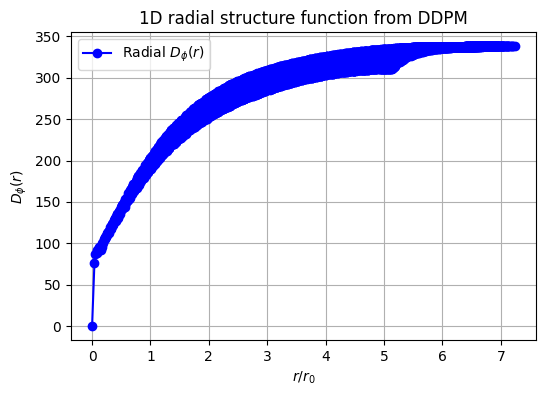

In [7]:
from aberration import PhaseScreen
import numpy as np
from matplotlib import pyplot as plt
from Train import eval
from tqdm import tqdm

# 生成评估样本
z_coes_array = eval(MODEL_CONFIG)
# %matplotlib inline

SIZE = 256
scr = PhaseScreen(N=SIZE)

for i, z_coes in tqdm(enumerate(z_coes_array), total=z_coes_array.shape[0]):
    scr.set_zernike_coeffients(list(z_coes))
    scr.add_pupil()
    psf = abs(scr.get_psf())
    psf = tf.cast(tf.convert_to_tensor(psf), tf.complex128)
    mask = tf.cast(tf.convert_to_tensor(np.ones([SIZE, SIZE])), tf.complex128)
    strn = abs(str_fcn2_ft(psf, mask, 1)).numpy()
    # plt.imshow(strn)
    # ================================
    # 1) 假设已有 2D 相位结构函数 Dphi_2d
    #    这里随机生成一个示例 (只作演示)
    Dphi_2d = strn  # 你实际应使用真正的结构函数数据

    # 2) 对 2D 数组做环平均
    radii_pix, Dphi_1d = radial_profile_2d_2(Dphi_2d)
    if i == 0:
        Dphi_1ds = np.zeros([z_coes_array.shape[0], Dphi_1d.shape[0]])
    Dphi_1ds[i] = Dphi_1d

Dphi_1d_mean_generated = np.mean(Dphi_1ds, axis=0)
assert Dphi_1d_mean_generated.shape == Dphi_1d.shape, "形状有误"
# 3) 转换为 r/r0
#    假设 1个像素 = 1个长度单位(可根据实际需求改成: r_phys = radii_pix * pixel_scale)
r0 = 25  # 示例: 设定 Fried 参数 r0 = 10 (与像素同单位)
r_over_r0_generated = radii_pix / r0

# 4) 绘图
plt.figure(figsize=(6, 4))
plt.plot(r_over_r0_generated, Dphi_1d_mean_generated, 'bo-', label='Radial $D_\phi(r)$')

plt.xlabel(r'$r / r_0$')
plt.ylabel(r'$D_\phi(r)$')
plt.title('1D radial structure function from DDPM')
plt.grid(True)
plt.legend()
plt.show()


# 样本数据结构函数

## 训练数据的平均结构函数

100%|██████████| 500/500 [01:32<00:00,  5.39it/s]


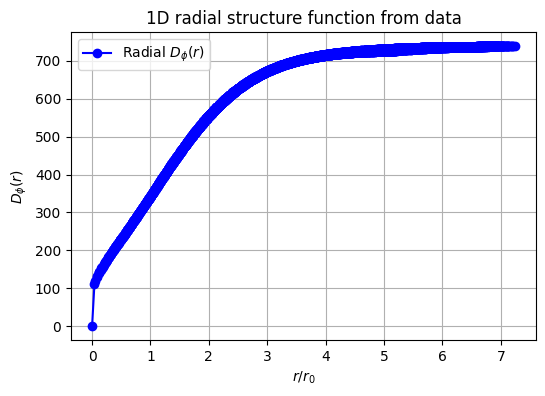

In [8]:
from aberration import PhaseScreen
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

# %matplotlib inline
SIZE = 256
scr = PhaseScreen(N=SIZE)
merged_series = pd.read_pickle('./DDPM_data/merged_data.pkl')
maxnum=min(merged_series.shape[0],500)
for i in tqdm(range(maxnum)):
    scr.set_zernike_coeffients(list(merged_series.iloc[i]))
    scr.add_pupil()
    psf = abs(scr.get_psf())
    psf = tf.cast(tf.convert_to_tensor(psf), tf.complex128)
    mask = tf.cast(tf.convert_to_tensor(np.ones([SIZE, SIZE])), tf.complex128)
    strn = abs(str_fcn2_ft(psf, mask, 1)).numpy()
    # plt.imshow(strn)
    # ================================
    # 1) 假设已有 2D 相位结构函数 Dphi_2d
    #    这里随机生成一个示例 (只作演示)
    Dphi_2d = strn  # 你实际应使用真正的结构函数数据

    # 2) 对 2D 数组做环平均
    radii_pix, Dphi_1d = radial_profile_2d_2(Dphi_2d)
    if i == 0:
        Dphi_1ds = np.zeros([maxnum, Dphi_1d.shape[0]])
    Dphi_1ds[i] = Dphi_1d

Dphi_1d_mean = np.mean(Dphi_1ds, axis=0)
assert Dphi_1d_mean.shape == Dphi_1d.shape, "形状有误"
# 3) 转换为 r/r0
#    假设 1个像素 = 1个长度单位(可根据实际需求改成: r_phys = radii_pix * pixel_scale)
r0 = 25  # 示例: 设定 Fried 参数 r0 = 10 (与像素同单位)
r_over_r0 = radii_pix / r0

# 4) 绘图
plt.figure(figsize=(6, 4))
plt.plot(r_over_r0, Dphi_1d_mean, 'bo-', label='Radial $D_\phi(r)$')

plt.xlabel(r'$r / r_0$')
plt.ylabel(r'$D_\phi(r)$')
plt.title('1D radial structure function from data')
plt.grid(True)
plt.legend()
plt.show()


## 训练数据结构函数与模型生成的结构函数对比

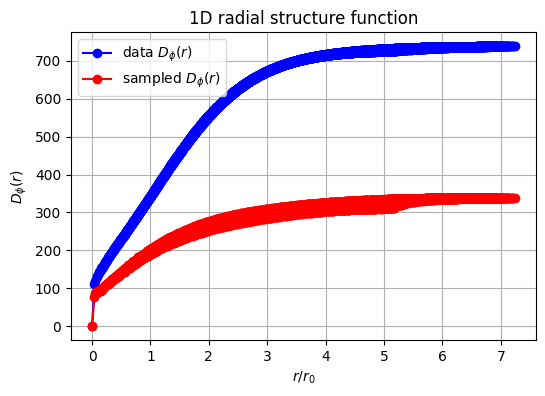

In [11]:
plt.figure(figsize=(6, 4))
plt.plot(r_over_r0, Dphi_1d_mean, 'bo-', label='data $D_\phi(r)$')
plt.plot(r_over_r0_generated, Dphi_1d_mean_generated, 'ro-', label='sampled $D_\phi(r)$')
plt.xlabel(r'$r / r_0$')
plt.ylabel(r'$D_\phi(r)$')
plt.title('1D radial structure function')
plt.grid(True)
plt.legend()
plt.show()

## 与Kolmogorov理论结构函数对比

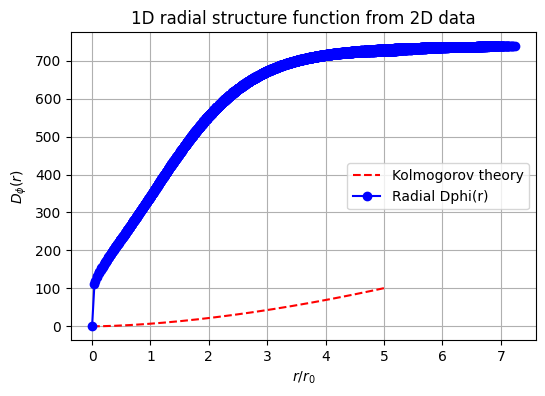

In [10]:
import numpy as np
import matplotlib.pyplot as plt

r0 = 0.2  # 示例: Fried 参数
r_max = 1.0  # 例如你的口径大小或更大范围

# 1) 生成无量纲坐标
x_theo = np.linspace(0, r_max / r0, 200)  # 0到(r_max/r0)均匀200点

# 2) 计算Kolmogorov理论
D_theo = 6.88 * (x_theo ** (5.0 / 3.0))

# 3) 绘制
plt.figure(figsize=(6, 4))
plt.plot(x_theo, D_theo, 'r--', label='Kolmogorov theory')
plt.xlabel(r'$r / r_0$')
plt.ylabel(r'$D_\phi(r)$')
plt.title('Kolmogorov $D_\phi(r)$ vs. $r/r_0$')
plt.legend()
plt.grid(True)

plt.plot(r_over_r0, Dphi_1d_mean, 'bo-', label='Radial Dphi(r)')
plt.xlabel(r'$r / r_0$')
plt.ylabel(r'$D_\phi(r)$')
plt.title('1D radial structure function from 2D data')
plt.grid(True)
plt.legend()
plt.show()
